# 08 · Distributed inference: batch scoring and online serving

After a model passes its evaluation gate it is used in two very different ways:

| | **Batch (offline) inference** | **Online inference** |
|---|---|---|
| example in this platform | score the whole candidate pool for active learning | a scientist / service asks "what would this design measure?" |
| unit of work | a shard of 10⁴–10⁶ rows | one request (1 row or a small list) |
| objective | **throughput** (rows/s), cost | **latency** (P50/P95/P99) at a given load |
| failure handling | retry the shard (pure function) | retry the request, shed load (HTTP 503) |
| repository | `inference/batch.py` → `predict_pool` (Ray actors) | `inference/serve.py` → `build_app` / `run` (Ray Serve) |

This notebook trains a small checkpoint, runs both paths, and measures the latency/throughput
trade-off of **dynamic batching**, **concurrency** and **replicas**.

## Conceptual model

```text
clients ──HTTP──► Serve proxy ──► router ──► replica queue (≤ max_ongoing_requests)
                                                 │
                                 @serve.batch: wait ≤ batch_wait_timeout_s
                                 or until max_batch_size requests
                                                 ▼
                                   one forward pass over B rows ──► B responses
```

**Cost model of a forward pass.** For a small MLP on CPU, the time to process a batch of $B$
rows is roughly affine, $T(B) = a + bB$, where $a$ (Python/dispatch/kernel-launch overhead) is
large relative to the per-row cost $b$. Throughput of a replica that always runs full batches:

$$X(B) = \frac{B}{a + bB} \;\xrightarrow{B\to\infty}\; \frac1b, \qquad X(1) = \frac{1}{a+b}.$$

Batching buys up to a factor $(a+b)/b$ in throughput, paid for with waiting time (up to
`batch_wait_timeout_s`) plus the longer forward pass.

**Little's law.** In any stable queueing system, the average number of requests in the system
$L$, the arrival (= completion) rate $\lambda$ and the mean time in system $W$ satisfy

$$L = \lambda W.$$

*Derivation sketch:* over a long window $[0,\tau]$, let $A(\tau)$ requests arrive and let
$\int_0^\tau N(t)\,dt$ be the area under the "requests in system" curve. Each request contributes
its sojourn time to the area, so area $\approx \sum_i W_i = A(\tau)\,\bar W$. Dividing by $\tau$:
$\bar N = (A(\tau)/\tau)\,\bar W = \lambda \bar W$. ∎

A closed-loop load generator with $c$ concurrent clients keeps $L=c$, so
$W = c/\lambda$: once the server saturates ($\lambda$ stops growing), **every extra concurrent
client adds latency and no throughput**. That is the regime where backpressure (queue caps,
HTTP 503) and autoscaling matter.

In [1]:
import os, sys, tempfile, time, warnings
from pathlib import Path

os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
os.environ.setdefault("MERGE_LOG_LEVEL", "WARNING")   # keep structlog output out of the notebook
os.environ.setdefault("RAY_DEDUP_LOGS", "1")
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (7.5, 3.6), "axes.grid": True,
                     "grid.alpha": 0.3})

# Every artifact this notebook creates lives in a fresh temp dir -- never in the repo's
# data/, artifacts/ or mlflow.db.
WORK = Path(tempfile.mkdtemp(prefix="nb08_"))
T0 = time.perf_counter()
print("workspace:", WORK)

workspace: /var/folders/vx/0jy3t_qx56q4d0qpnmgs008r0000gn/T/nb08_48oyg27b


In [2]:
import json, socket, concurrent.futures as cf
import requests, torch
import ray
from ray import serve

from merge_platform.config import PlatformConfig
from merge_platform.data.datasets import ArrayDataset, records_to_frame, train_val_split
from merge_platform.data.generation import (generate_candidate_pool, initial_observations,
                                            make_oracle, pool_features)
from merge_platform.inference import Predictor
from merge_platform.inference.batch import predict_pool, predict_pool_local
from merge_platform.inference.serve import run as serve_run
from merge_platform.models import count_parameters
from merge_platform.ray_runtime.cluster import ensure_ray
from merge_platform.training import Trainer

MC = 30   # MC-dropout samples per prediction (cfg.evaluation.mc_samples)
cfg = PlatformConfig.for_tests(WORK, **{"data.pool_size": 20_000, "model.hidden_dims": [256, 256, 128],
                                        "training.epochs": 5, "evaluation.mc_samples": MC})
pool = generate_candidate_pool(cfg)
oracle = make_oracle(cfg)
obs = records_to_frame(initial_observations(pool, oracle, n=400, seed=cfg.seed))
tr, va = train_val_split(obs, 0.2, cfg.seed)
result = Trainer(cfg).train(ArrayDataset.from_frame(tr), ArrayDataset.from_frame(va),
                            checkpoint_dir=WORK / "ckpt")
CKPT = result.checkpoint_path
predictor = Predictor.from_checkpoint(CKPT)
print(f"checkpoint {CKPT.name}: {result.n_parameters:,} parameters, val_rmse={result.metrics['val_rmse']:.3f}")

checkpoint epoch_0005: 207,745 parameters, val_rmse=0.437


## 1 · Measure the forward-pass cost model in-process

Before any distributed machinery: how long does one MC-dropout prediction over a batch of $B$
rows take on this machine (single thread, like one small replica)?

In [3]:
X_pool = pool_features(pool, cfg.data.n_features)
torch.set_num_threads(1)
sizes = [1, 2, 4, 8, 16, 32, 64, 128]
cost = []
for B in sizes:
    xb = X_pool[:B]
    predictor.predict_with_uncertainty(xb, MC)                     # warm-up
    reps = 20 if B <= 16 else 8
    t0 = time.perf_counter()
    for _ in range(reps):
        predictor.predict_with_uncertainty(xb, MC)
    cost.append((time.perf_counter() - t0) / reps * 1e3)
torch.set_num_threads(os.cpu_count() or 1)
b_ms, a_ms = np.polyfit(sizes, cost, 1)
cost_df = pd.DataFrame({"B": sizes, "ms_per_batch": cost,
                        "rows_per_s": [B / (c / 1e3) for B, c in zip(sizes, cost)]})
print(f"fit: T(B) = {a_ms:.2f} ms + {b_ms:.3f} ms * B   ->  max batching gain (a+b)/b = {(a_ms + b_ms) / b_ms:.0f}x")
cost_df

fit: T(B) = 2.34 ms + 0.075 ms * B   ->  max batching gain (a+b)/b = 32x


,B,ms_per_batch,rows_per_s
0,1,2.0411,489.9434
1,2,2.6813,745.9132
2,4,2.6987,1482.1780
3,8,2.9658,2697.4305
4,16,3.4553,4630.5982
5,32,4.8237,6633.8502
6,64,7.3216,8741.2599
7,128,11.7851,10861.2164


## 2 · Batch inference: Ray actors vs in-process reference

`predict_pool` puts the checkpoint bytes and the pool matrix into the object store once, starts
`n_actors` `PredictorActor`s (each loads the model **once** — the model cache), and streams
shards to them with at most `max_in_flight` outstanding requests (**backpressure** via
`ray.wait`). MC-dropout seeds are per *shard*, so the result is identical to the in-process
`predict_pool_local` no matter which actor scored which shard.

In [4]:
ensure_ray(num_cpus=8, log_to_driver=False)
print("cluster:", {k: v for k, v in ray.cluster_resources().items() if k in ("CPU", "GPU", "memory")})
# (On Apple silicon Ray advertises GPU: 1 for Metal; PyTorch cannot use it via CUDA, so the
#  platform decides GPU use with torch.cuda.is_available() -- see batch.actor_resources.)

t0 = time.perf_counter()
local = predict_pool_local(CKPT, pool, shard_size=2_500, mc_samples=10, seed=0)
t_local = time.perf_counter() - t0
dist_df, stats = predict_pool(CKPT, pool, n_actors=4, shard_size=2_500, mc_samples=10, seed=0,
                              max_in_flight=4, return_stats=True)
print(f"rows={len(pool):,}  local: {t_local:.2f}s   ray (4 actors, incl. actor start): {stats['wall_s']:.2f}s")
print("identical to local reference:",
      np.allclose(local.pred_mean, dist_df.pred_mean) and np.allclose(local.pred_std, dist_df.pred_std))
pd.DataFrame(stats["actors"])[["pid", "load_s", "shards_served", "rows_served"]]

2026-09-27 08:20:59,677	INFO worker.py:2015 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 


cluster: {'CPU': 8.0, 'GPU': 1.0, 'memory': 14911127552.0}


rows=20,000  local: 0.44s   ray (4 actors, incl. actor start): 3.31s
identical to local reference: True


,pid,load_s,shards_served,rows_served
0,37641,0.0146,2,5000
1,37644,0.0154,2,5000
2,37643,0.0154,2,5000
3,37642,0.0204,2,5000


On a laptop-sized pool the actor start-up (a new process, `import torch`, loading the model)
is comparable to the scoring itself; the design pays off when the pool is large, when a
long-lived actor pool is reused across calls, or when actors sit on GPU nodes. Note the
per-actor `load_s`: model loading is paid once per actor, not once per shard.

## 3 · Online serving with Ray Serve

`merge_platform.inference.serve.run(..., blocking=False)` starts Serve on a port and deploys
`SurrogateModelDeployment` with the given `max_batch_size` / `num_replicas`. Calling it again
with the same app name performs a **rolling replacement**.

In [5]:
def free_port():
    with socket.socket() as s:
        s.bind(("127.0.0.1", 0))
        return s.getsockname()[1]

PORT = free_port()
URL = f"http://127.0.0.1:{PORT}"

def deploy(max_batch_size, num_replicas=1, version="1"):
    serve_run(CKPT, version, cfg, port=PORT, blocking=False, max_batch_size=max_batch_size,
              num_replicas=num_replicas, mc_samples=MC, batch_wait_timeout_s=0.005)
    for _ in range(100):                                   # wait for the HTTP route
        try:
            if requests.get(f"{URL}/health", timeout=2).ok:
                return requests.get(f"{URL}/model-info", timeout=5).json()
        except requests.RequestException:
            pass
        time.sleep(0.2)
    raise RuntimeError("serve app did not become healthy")

info = deploy(max_batch_size=1)
print(json.dumps({k: info[k] for k in ("model_version", "n_parameters", "load_s", "serving_config")}, indent=1))
print(requests.post(f"{URL}/predict", json={"features": X_pool[0].tolist()}).json())

INFO 2026-09-27 08:21:09,083 serve 37495 -- Started Serve in namespace "serve".


INFO 2026-09-27 08:21:12,237 serve 37495 -- Application 'surrogate' is ready at http://127.0.0.1:54921/.


{
 "model_version": "1",
 "n_parameters": 207745,
 "load_s": 0.006,
 "serving_config": {
  "max_batch_size": 1,
  "batch_wait_timeout_s": 0.005,
  "mc_samples": 30,
  "torch_threads": 4
 }
}
{'mean': 2.513670118609247, 'std': 0.12150392757600198, 'model_version': '1'}


In [6]:
ROWS = X_pool[:512].tolist()

def load_test(concurrency, n_requests=240):
    # Closed-loop load: `concurrency` clients, each sends its next request when the previous returns.
    before = requests.get(f"{URL}/model-info").json()["metrics"]
    lat = []
    def client(k):
        s = requests.Session(); out = []
        for i in range(k, n_requests, concurrency):
            t = time.perf_counter()
            r = s.post(f"{URL}/predict", json={"features": ROWS[i % len(ROWS)]}, timeout=30)
            r.raise_for_status()
            out.append((time.perf_counter() - t) * 1e3)
        return out
    t0 = time.perf_counter()
    with cf.ThreadPoolExecutor(concurrency) as ex:
        for part in ex.map(client, range(concurrency)):
            lat += part
    wall = time.perf_counter() - t0
    after = requests.get(f"{URL}/model-info").json()["metrics"]
    d_batches = after["batches_total"] - before["batches_total"]
    d_rows = after["rows_predicted"] - before["rows_predicted"]
    lat = np.array(lat)
    return {"concurrency": concurrency, "throughput_rps": len(lat) / wall,
            "p50_ms": np.percentile(lat, 50), "p95_ms": np.percentile(lat, 95),
            "p99_ms": np.percentile(lat, 99), "mean_ms": lat.mean(),
            "mean_batch": d_rows / max(d_batches, 1)}

CONC = [1, 4, 16, 48]
results = []
for mbs in (1, 32):
    if mbs != 1:
        deploy(max_batch_size=mbs, version=f"mbs{mbs}")          # rolling update of the same app
    load_test(4, 40)                                           # warm-up
    for c in CONC:
        results.append({"config": f"1 replica, max_batch_size={mbs}", **load_test(c)})
pd.DataFrame(results).set_index(["config", "concurrency"])

INFO 2026-09-27 08:21:18,938 serve 37495 -- Application 'surrogate' is ready at http://127.0.0.1:54921/.


throughput_rps    p50_ms    p95_ms    p99_ms   mean_ms  mean_batch
config                       concurrency                                                                    
1 replica, max_batch_size=1  1                  233.2009    4.2602    4.5811    4.7598    4.2873      1.0000
                             4                  313.3052   12.7050   13.1385   13.4510   12.6983      1.0000
                             16                 311.8311   51.2529   51.8097   52.4369   49.9351      1.0000
                             48                 266.7477  183.0251  199.0667  204.8941  166.1863      1.0000
1 replica, max_batch_size=32 1                   95.0084   10.5161   11.2184   11.4321   10.5244      1.0000
                             4                  282.8676   13.8330   16.0294   17.1535   14.1236      4.0000
                             16                 654.3736   23.9347   27.1751   30.8762   23.9627      8.0000
                             48                 686.0209   68.7512   74.4730   77.1394   64.8560      8.8889

**Reading the table.**

* With `max_batch_size=1`, every request is its own forward pass. Throughput saturates at about
  $1/T(1)$ plus HTTP overhead, and beyond that latency grows linearly with concurrency — exactly
  $W = c/\lambda$.
* With `max_batch_size=32`, concurrent requests are coalesced (see `mean_batch`, measured from the
  replica's own counters on `/model-info`). Throughput is roughly 2x higher at moderate
  concurrency and latency at high load is far lower. At concurrency 1 there is nothing to
  batch; a request may even wait up to `batch_wait_timeout_s` for company, so P50 *rises*.
* On one laptop the load generator (Python threads), the HTTP proxy and the replica share the
  same cores. At the highest concurrency the client and proxy — not the model — become the
  bottleneck (throughput stops growing, observed batches stay well below 32). Real load tests
  run the generator on separate machines.

### Little's law check

For a closed-loop test, $L = c$ exactly, so $\lambda \cdot \bar W$ should reproduce the concurrency:

In [7]:
res_df = pd.DataFrame(results)
res_df["lambda*W (=L)"] = res_df.throughput_rps * res_df.mean_ms / 1e3
res_df[["config", "concurrency", "throughput_rps", "mean_ms", "lambda*W (=L)"]]

,config,concurrency,throughput_rps,mean_ms,lambda*W (=L)
0,"1 replica, max_batch_size=1",1,233.2009,4.2873,0.9998
1,"1 replica, max_batch_size=1",4,313.3052,12.6983,3.9785
2,"1 replica, max_batch_size=1",16,311.8311,49.9351,15.5713
3,"1 replica, max_batch_size=1",48,266.7477,166.1863,44.3298
4,"1 replica, max_batch_size=32",1,95.0084,10.5244,0.9999
5,"1 replica, max_batch_size=32",4,282.8676,14.1236,3.9951
6,"1 replica, max_batch_size=32",16,654.3736,23.9627,15.6806
7,"1 replica, max_batch_size=32",48,686.0209,64.8560,44.4926


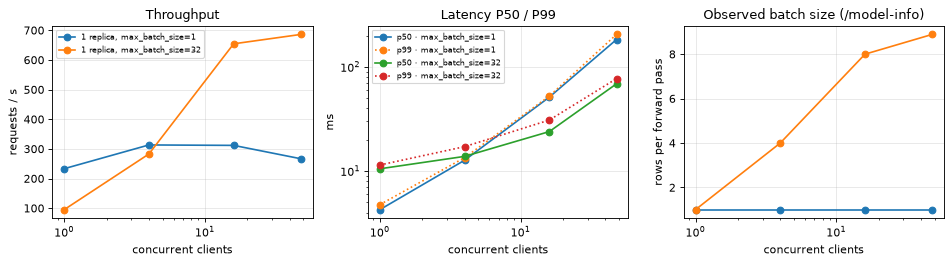

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for cfg_name, g in res_df.groupby("config"):
    axes[0].plot(g.concurrency, g.throughput_rps, "o-", label=cfg_name)
    for q, ls in (("p50_ms", "-"), ("p99_ms", ":")):
        axes[1].plot(g.concurrency, g[q], ls, marker="o", label=f"{q[:3]} · {cfg_name.split(', ')[1]}")
    axes[2].plot(g.concurrency, g.mean_batch, "o-", label=cfg_name)
axes[0].set(xscale="log", xlabel="concurrent clients", ylabel="requests / s", title="Throughput")
axes[1].set(xscale="log", yscale="log", xlabel="concurrent clients", ylabel="ms", title="Latency P50 / P99")
axes[2].set(xscale="log", xlabel="concurrent clients", ylabel="rows per forward pass",
            title="Observed batch size (/model-info)")
axes[0].legend(fontsize=7); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

### Replicas

A replica is a Ray actor with its own copy of the model. Two replicas double the compute
available — but only if the machine has spare cores; on a single laptop they compete with the
load generator and the proxy. Serve routes each request to the replica with the shorter
queue ("power of two choices").

In [9]:
info2 = deploy(max_batch_size=32, num_replicas=2, version="mbs32x2")
load_test(8, 40)
rep = load_test(48)
one = res_df[(res_df.config == "1 replica, max_batch_size=32") & (res_df.concurrency == 48)].iloc[0]
print(f"throughput ratio 2 replicas / 1 replica at 48 clients: {rep['throughput_rps'] / one['throughput_rps']:.2f}x")
pd.DataFrame([{"setup": "1 replica", **{k: one[k] for k in ("throughput_rps", "p50_ms", "p99_ms")}},
              {"setup": "2 replicas", **{k: rep[k] for k in ("throughput_rps", "p50_ms", "p99_ms")}}]
             ).set_index("setup")

INFO 2026-09-27 08:21:29,617 serve 37495 -- Application 'surrogate' is ready at http://127.0.0.1:54921/.


throughput ratio 2 replicas / 1 replica at 48 clients: 1.32x


,throughput_rps,p50_ms,p99_ms
setup,,,
1 replica,686.0209,68.7512,77.1394
2 replicas,904.8254,48.8786,66.5716


Whether the second replica helps depends on where the bottleneck is. On a laptop that is
already saturated by the load generator and proxy, a second replica mostly competes for the
same cores — and it **halves the concurrency each replica sees**, so dynamic batches get
smaller and per-row cost rises. Replicas scale throughput when they bring *new* hardware
(another node, another GPU) and each replica still receives enough concurrent traffic to fill
its batches. Results on a shared laptop also vary noticeably from run to run.

## 4 · Backpressure, model loading, accelerator memory, autoscaling

**Backpressure** (in `build_app`): `max_ongoing_requests = max(2·max_batch_size, 32)` per
replica — a full batch can form, but no replica accepts unbounded work; excess requests wait in
the proxy/handle queue, and beyond `max_queued_requests = 4096` Serve answers **HTTP 503**
instead of letting latency grow without bound (the Little's-law regime above). Clients should
treat 503 as "retry later with jitter". Batch inference applies the same idea on the driver:
`predict_pool(max_in_flight=...)` keeps at most that many shard calls outstanding.

**Model loading.** Each replica loads the checkpoint in `__init__`
(`Predictor.from_checkpoint`); `/model-info` reports `load_s`. Scale-up latency = pod/actor start +
image/env + model load; for large models this dominates and is the reason to keep a warm minimum
of replicas. On a multi-node cluster the checkpoint path must be on shared storage (or the
checkpoint baked into the image) — the batch path avoids that by shipping checkpoint bytes via
the object store.

**Accelerator memory** — back-of-the-envelope for this model (fp32):

In [10]:
n_params = count_parameters(predictor.model)
widest = max(cfg.model.hidden_dims)
rows = []
for B in (1, 64, 1024, 65_536):
    weights = n_params * 4
    acts = B * MC * widest * 4 * 4          # ~4 live activation tensors of width `widest` per MC pass
    rows.append({"batch rows": B, "weights (MB)": weights / 2**20,
                 "activations x MC (MB)": acts / 2**20})
print(f"{n_params:,} parameters; CUDA available here: {torch.cuda.is_available()}")
pd.DataFrame(rows)

207,745 parameters; CUDA available here: False


,batch rows,weights (MB),activations x MC (MB)
0,1,0.7925,0.1172
1,64,0.7925,7.5000
2,1024,0.7925,120.0000
3,65536,0.7925,7680.0000


Weights are tiny here; the MC-dropout activations (×`mc_samples`) dominate at large batch sizes.
That is why `predict_batch` chunks a large request to `max_batch_size` rows and why batch
inference uses bounded shards — a single huge request must not OOM a GPU replica that other
requests share. For multi-GB models the balance flips: weights dominate, one replica per GPU,
and fractional `num_gpus` packing is only possible when several models fit together.

**Autoscaling.** `build_app(..., autoscaling=True)` replaces `num_replicas` by

```python
{"min_replicas": 1, "initial_replicas": n_rep, "max_replicas": max(n_rep, max_replicas),
 "target_ongoing_requests": max(1, max_batch_size // 2),
 "upscale_delay_s": 5, "downscale_delay_s": 30}
```

Serve adds replicas when the average number of ongoing requests per replica exceeds the target
(i.e. it controls $L$ per replica, hence latency via Little's law). On Kubernetes, new replicas
that do not fit become pending Ray resource demand → the KubeRay autoscaler adds worker pods →
the node autoscaler adds nodes (notebook 12). Each layer adds start-up latency; scale-down is
delayed longer than scale-up to avoid flapping.

## Connection to this repository

| Concept | Where |
|---|---|
| framework-free model wrapper, MC dropout, raw units | `src/merge_platform/inference/predictor.py` → `Predictor.from_checkpoint`, `predict`, `predict_with_uncertainty` |
| batch scoring, object store, model-cache actors, `max_in_flight` backpressure | `src/merge_platform/inference/batch.py` → `predict_pool`, `PredictorActor`, `actor_resources`, `predict_pool_local` |
| Serve deployment, `@serve.batch`, metrics on `/model-info` | `src/merge_platform/inference/serve.py` → `SurrogateModelDeployment`, `_ServeMetrics` |
| replica resources, queue caps, autoscaling config | `serve.py` → `replica_resources`, `build_app` |
| start / rolling replacement | `serve.py` → `run(..., blocking=False)`; `make serve`, `scripts/query_model.py` |
| Kubernetes shape | `infra/k8s/rayservice.yaml` (RayService, `serve-cpu` worker group) |

## Failure modes

* **Unbounded queues** — without a queue cap, overload shows up as ever-growing latency and
  eventually OOM rather than a clean 503.
* **Tail latency from batching** — a lone request can wait `batch_wait_timeout_s`; set it well
  below the latency SLO. Very large `max_batch_size` raises P99 under bursty load.
* **Oversubscription** — replicas × torch threads > cores gives worse throughput than fewer
  replicas (threads fight for cores). `replica_resources` clamps threads per replica.
* **Model load storms** — scaling from 0 → N replicas simultaneously reads the checkpoint N times;
  cold starts violate SLOs. Keep `min_replicas ≥ 1` for online paths.
* **Non-reproducible responses** — MC-dropout masks span the batch, so a row's `std` can vary
  slightly with batch composition (documented in `SurrogateModelDeployment._infer`). Batch
  inference seeds per shard to stay deterministic.
* **Version skew** — during a rolling update, two model versions answer concurrently; every
  response carries `model_version` so downstream consumers can tell.

## Exercise

1. Re-run the sweep with `batch_wait_timeout_s=0.05`. What happens to P50 at concurrency 1 and
   to throughput at concurrency 48? Explain with the cost model $T(B)=a+bB$.
2. Using the fitted $a, b$ from §1, predict the saturation throughput for `max_batch_size=32`
   and compare with the measurement. Where does the remaining gap come from?
3. Write a small open-loop load generator (fixed arrival rate $\lambda$, Poisson inter-arrivals)
   and find the $\lambda$ at which P99 exceeds 100 ms for each configuration.

In [11]:
serve.shutdown()
ray.shutdown()
import shutil
shutil.rmtree(WORK, ignore_errors=True)
print(f"done in {time.perf_counter() - T0:.1f}s; Serve and Ray shut down, workspace removed")

(raylet) Task ServeController.graceful_shutdown failed. There are infinite retries remaining, so the task will be retried. Error: The actor is dead because it was killed by `ray.kill`.


done in 43.8s; Serve and Ray shut down, workspace removed
